# 🇹🇳 Tunisian Dataset - Final Cleaning, Exploration & Hugging Face Upload

**Goal**: Perform final data cleaning, comprehensive exploration, and push the dataset to Hugging Face.

Sections:
1. Setup & Load Data
2. Final Cleaning & Deduplication
3. Data Validation
4. Exploratory Analysis
5. Dataset Preparation for HF
6. Upload to Hugging Face

## Section 1: Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# For Hugging Face
try:
    from datasets import Dataset, DatasetDict
    from huggingface_hub import HfApi, login
    HF_AVAILABLE = True
except ImportError:
    HF_AVAILABLE = False
    print("⚠️  Hugging Face datasets/hub not installed")
    print("   Install with: pip install datasets huggingface-hub")

# Setup
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
PALETTE = ['#2E86AB', '#E84855', '#F4A261', '#52B788', '#9B5DE5', '#F77F00']

# Paths
data_dir = Path("C:\\Users\\user\\OneDrive\\Bureau\\TunisianDialogSystem\\llm\\sft\\data")
augmented_data_path = data_dir / "augmented" / "augmented_all_merged.csv"
final_output_dir = data_dir / "final"
final_output_dir.mkdir(parents=True, exist_ok=True)

print("✅ Imports complete")
print(f"HF Hub available: {HF_AVAILABLE}")
print(f"Data directory: {data_dir.resolve()}")
print(f"Augmented data path: {augmented_data_path.resolve()}")
print(f"Final output directory: {final_output_dir.resolve()}")

✅ Imports complete
HF Hub available: True
Data directory: C:\Users\user\OneDrive\Bureau\TunisianDialogSystem\llm\sft\data
Augmented data path: C:\Users\user\OneDrive\Bureau\TunisianDialogSystem\llm\sft\data\augmented\augmented_all_merged.csv
Final output directory: C:\Users\user\OneDrive\Bureau\TunisianDialogSystem\llm\sft\data\final


In [2]:
# Load augmented data
try:
    df = pd.read_csv(augmented_data_path)
    print(f"✅ Loaded augmented data")
    print(f"   Shape: {df.shape}")
    print(f"   Columns: {list(df.columns)}")
    print(f"\n📊 Data preview:")
    print(df.head(3))
except FileNotFoundError:
    print(f"❌ File not found: {augmented_data_path}")
    print(f"   Trying alternative paths...")
    alt_paths = [
        data_dir / "augmented_all_merged.csv",
        data_dir / "augmented" / "augmented_all.csv",
        data_dir / "cleaned.csv",
    ]
    for alt_path in alt_paths:
        if alt_path.exists():
            df = pd.read_csv(alt_path)
            print(f"✅ Found at: {alt_path}")
            break
    else:
        print("❌ Could not find augmented data")
        df = None

if df is not None:
    print(f"\n🔍 Data info:")
    print(df.info())

✅ Loaded augmented data
   Shape: (43687, 4)
   Columns: ['category', 'instruction', 'response', 'augmentation_type']

📊 Data preview:
             category                                        instruction  \
0  cultural_knowledge  أعطيني لمحة على أشهر أنواع السلايط في الكوجينة...   
1        storytelling  كيفاش يعتبر تكريم كريم بقير وزهرة سليم في مجال...   
2  cultural_knowledge  كيفاش تنجم تونس تحافظ على التراث الفلكي الإسلا...   

                                            response augmentation_type  
0  الكوجينة التونسية معروفة بتنوع السلايط متاعها،...               NaN  
1  تكريم كريم بقير وزهرة سليم (مؤسسي InstaDeep) ي...               NaN  
2  تونس تنجم تواصل في الثنية هاذي عن طريق:\n• عمل...               NaN  

🔍 Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43687 entries, 0 to 43686
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   category           43687 non-null  object
 1   

## Section 2: Final Cleaning & Deduplication

In [3]:
if df is not None:
    df_original = df.copy()
    print(f"Starting with: {len(df)} rows\n")
    
    # Step 1: Remove null/empty values
    print("🔹 Step 1: Removing null/empty values")
    before = len(df)
    df = df.dropna(subset=['instruction', 'response'])
    df = df[(df['instruction'].str.strip() != '') & (df['response'].str.strip() != '')]
    print(f"   Removed: {before - len(df)} rows")
    print(f"   Remaining: {len(df)} rows\n")
    
    # Step 2: Remove exact duplicates
    print("🔹 Step 2: Removing exact duplicates")
    before = len(df)
    df = df.drop_duplicates()
    print(f"   Removed: {before - len(df)} rows")
    print(f"   Remaining: {len(df)} rows\n")
    
    # Step 3: Remove (instruction, response) pair duplicates
    print("🔹 Step 3: Removing duplicate (instruction, response) pairs")
    before = len(df)
    df = df.drop_duplicates(subset=['instruction', 'response'], keep='first')
    print(f"   Removed: {before - len(df)} rows")
    print(f"   Remaining: {len(df)} rows\n")
    
    # Step 4: Remove extremely short entries
    print("🔹 Step 4: Removing extremely short entries")
    before = len(df)
    df['instr_len'] = df['instruction'].str.len()
    df['resp_len'] = df['response'].str.len()
    df = df[(df['instr_len'] >= 3) & (df['resp_len'] >= 3)]
    print(f"   Removed: {before - len(df)} rows")
    print(f"   Remaining: {len(df)} rows\n")
    
    # Step 5: Clean whitespace
    print("🔹 Step 5: Cleaning whitespace")
    df['instruction'] = df['instruction'].str.strip()
    df['response'] = df['response'].str.strip()
    print(f"   ✓ Cleaned all whitespace\n")
    
    # Step 6: Remove text within parentheses from instructions
    print("🔹 Step 6: Removing parenthetical content from instructions")
    df['instruction'] = df['instruction'].apply(lambda x: re.sub(r'\s*\([^)]*\)', '', x).strip())
    print(f"   ✓ Removed all parenthetical content\n")
    
    # Step 7: Drop helper columns
    df = df.drop(columns=['instr_len', 'resp_len'], errors='ignore')
    
    print(f"✅ Final cleaning complete!")
    print(f"   Total rows: {len(df):,}")
    print(f"   Duplicates removed: {len(df_original) - len(df):,}")
    print(f"   Retention rate: {len(df)/len(df_original)*100:.1f}%")

Starting with: 43687 rows

🔹 Step 1: Removing null/empty values
   Removed: 0 rows
   Remaining: 43687 rows

🔹 Step 2: Removing exact duplicates
   Removed: 10813 rows
   Remaining: 32874 rows

🔹 Step 3: Removing duplicate (instruction, response) pairs
   Removed: 1185 rows
   Remaining: 31689 rows

🔹 Step 4: Removing extremely short entries
   Removed: 20 rows
   Remaining: 31669 rows

🔹 Step 5: Cleaning whitespace
   ✓ Cleaned all whitespace

🔹 Step 6: Removing parenthetical content from instructions
   ✓ Removed all parenthetical content

✅ Final cleaning complete!
   Total rows: 31,669
   Duplicates removed: 12,018
   Retention rate: 72.5%


## Section 3: Data Validation

In [4]:
if df is not None:
    print("✅ Data Validation Checks\n")
    
    # Check 1: No nulls
    null_check = df.isnull().sum().sum()
    print(f"✓ Null values: {null_check}")
    
    # Check 2: Required columns
    required_cols = ['instruction', 'response']
    has_required = all(col in df.columns for col in required_cols)
    print(f"✓ Required columns present: {has_required}")
    
    # Check 3: No empty strings
    empty_instr = (df['instruction'] == '').sum()
    empty_resp = (df['response'] == '').sum()
    print(f"✓ Empty instructions: {empty_instr}")
    print(f"✓ Empty responses: {empty_resp}")
    
    # Check 4: Text length statistics
    df['instr_words'] = df['instruction'].str.split().str.len()
    df['resp_words'] = df['response'].str.split().str.len()
    
    print(f"\n📊 Text Length Statistics:")
    print(f"   Instructions:")
    print(f"     - Min words: {df['instr_words'].min()}")
    print(f"     - Max words: {df['instr_words'].max()}")
    print(f"     - Avg words: {df['instr_words'].mean():.1f}")
    print(f"     - Median words: {df['instr_words'].median():.0f}")
    
    print(f"\n   Responses:")
    print(f"     - Min words: {df['resp_words'].min()}")
    print(f"     - Max words: {df['resp_words'].max()}")
    print(f"     - Avg words: {df['resp_words'].mean():.1f}")
    print(f"     - Median words: {df['resp_words'].median():.0f}")
    
    # Check 5: Category coverage
    if 'category' in df.columns:
        print(f"\n📊 Category Coverage:")
        print(f"   Total categories: {df['category'].nunique()}")
        print(f"   Samples per category (top 10):")
        print(df['category'].value_counts().head(10))
    
    print(f"\n✅ Validation complete! Dataset is ready for HF upload.")

✅ Data Validation Checks

✓ Null values: 11836
✓ Required columns present: True
✓ Empty instructions: 0
✓ Empty responses: 0

📊 Text Length Statistics:
   Instructions:
     - Min words: 2
     - Max words: 87
     - Avg words: 10.2
     - Median words: 9

   Responses:
     - Min words: 1
     - Max words: 166
     - Avg words: 36.1
     - Median words: 33

📊 Category Coverage:
   Total categories: 9
   Samples per category (top 10):
category
advice_guidance             9738
cultural_knowledge          6429
general_knowledge           4349
task_oriented               3523
student_life                2360
opinions_recommendations    2216
emotional_support           1067
everyday_conversation       1033
storytelling                 954
Name: count, dtype: int64

✅ Validation complete! Dataset is ready for HF upload.


## Section 4: Exploratory Analysis

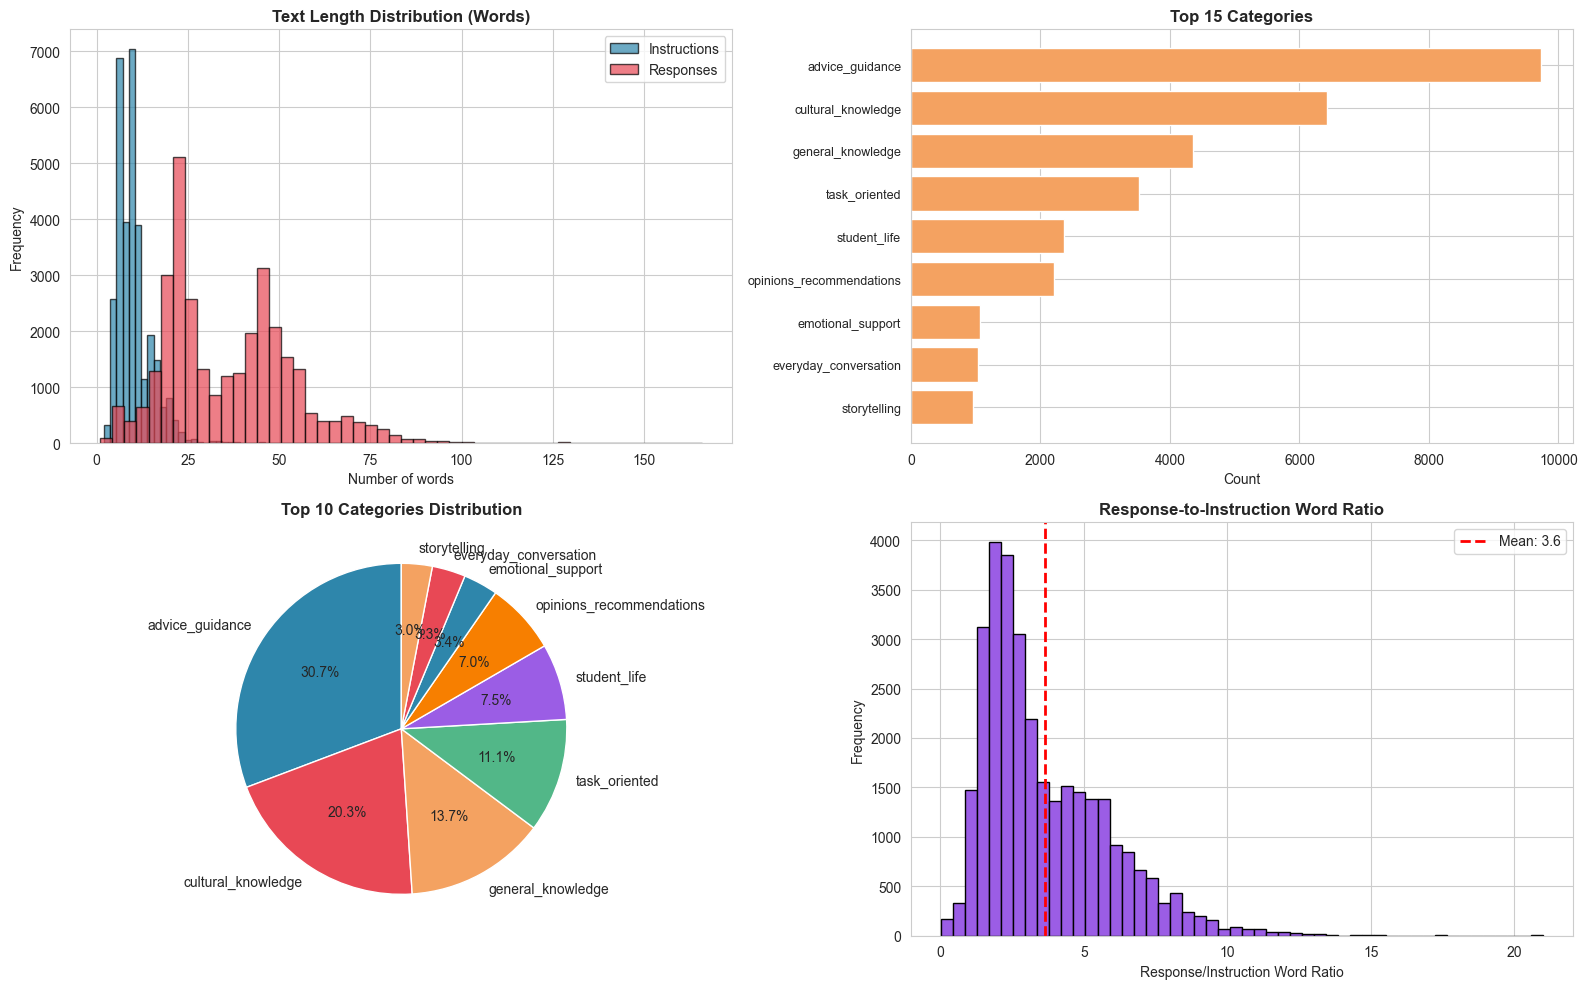

✅ Saved exploration plot to C:\Users\user\OneDrive\Bureau\TunisianDialogSystem\llm\sft\data\final\dataset_exploration.png

📈 Dataset Summary Statistics:
   Total samples: 31,669
   Total words (instructions): 322,762
   Total words (responses): 1,142,104
   Average words per instruction: 10.2
   Average words per response: 36.1


In [5]:
if df is not None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Plot 1: Text length distribution
    axes[0, 0].hist(df['instr_words'], bins=50, color=PALETTE[0], alpha=0.7, edgecolor='black', label='Instructions')
    axes[0, 0].hist(df['resp_words'], bins=50, color=PALETTE[1], alpha=0.7, edgecolor='black', label='Responses')
    axes[0, 0].set_xlabel('Number of words')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Text Length Distribution (Words)', fontweight='bold')
    axes[0, 0].legend()
    
    # Plot 2: Category distribution (top 15)
    if 'category' in df.columns:
        top_cats = df['category'].value_counts().head(15)
        axes[0, 1].barh(range(len(top_cats)), top_cats.values, color=PALETTE[2])
        axes[0, 1].set_yticks(range(len(top_cats)))
        axes[0, 1].set_yticklabels(top_cats.index, fontsize=9)
        axes[0, 1].set_xlabel('Count')
        axes[0, 1].set_title('Top 15 Categories', fontweight='bold')
        axes[0, 1].invert_yaxis()
    
    # Plot 3: Sample distribution across categories
    if 'category' in df.columns:
        sample_counts = df['category'].value_counts().head(10)
        axes[1, 0].pie(sample_counts.values, labels=sample_counts.index, autopct='%1.1f%%',
                       colors=PALETTE, startangle=90)
        axes[1, 0].set_title('Top 10 Categories Distribution', fontweight='bold')
    
    # Plot 4: Response/Instruction word ratio
    df['word_ratio'] = df['resp_words'] / (df['instr_words'] + 1)
    axes[1, 1].hist(df['word_ratio'], bins=50, color=PALETTE[4], edgecolor='black')
    axes[1, 1].axvline(df['word_ratio'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["word_ratio"].mean():.1f}')
    axes[1, 1].set_xlabel('Response/Instruction Word Ratio')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Response-to-Instruction Word Ratio', fontweight='bold')
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.savefig(final_output_dir / 'dataset_exploration.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved exploration plot to {final_output_dir / 'dataset_exploration.png'}")
    
    # Summary statistics
    print(f"\n📈 Dataset Summary Statistics:")
    print(f"   Total samples: {len(df):,}")
    print(f"   Total words (instructions): {df['instr_words'].sum():,}")
    print(f"   Total words (responses): {df['resp_words'].sum():,}")
    print(f"   Average words per instruction: {df['instr_words'].mean():.1f}")
    print(f"   Average words per response: {df['resp_words'].mean():.1f}")

In [6]:
# Shuffle the data
if df is not None:
    print("🔹 Shuffling the data...")
    df = df.sample(frac=1.0, random_state=42).reset_index(drop=True)
    print(f"✓ Data shuffled")
    print(f"   Total samples: {len(df):,}\n")

🔹 Shuffling the data...
✓ Data shuffled
   Total samples: 31,669



## Section 5: Prepare for Hugging Face

In [7]:
if df is not None and HF_AVAILABLE:
    print("🎯 Preparing dataset for Hugging Face\n")
    
    # Step 1: Ensure required columns
    print("🔹 Step 1: Preparing columns")
    required_cols = {'instruction', 'response'}
    
    # Keep only essential columns for HF
    essential_cols = ['instruction', 'response']
    optional_cols = [col for col in df.columns if col in ['category']]
    cols_to_keep = essential_cols + optional_cols
    
    df_hf = df[cols_to_keep].copy()
    print(f"   Columns to upload: {list(df_hf.columns)}")
    print(f"   Shape: {df_hf.shape}\n")
    
    # Step 2: Create HF Dataset
    print("🔹 Step 2: Converting to Hugging Face Dataset format")
    hf_dataset = Dataset.from_pandas(df_hf)
    print(f"   ✓ Dataset created")
    print(f"   Features: {hf_dataset.features}\n")
    
    # Step 3: Create train/test split (optional)
    print("🔹 Step 3: Creating train/test split (80/20)")
    split_dataset = hf_dataset.train_test_split(test_size=0.2, seed=42)
    print(f"   Train samples: {len(split_dataset['train']):,}")
    print(f"   Test samples: {len(split_dataset['test']):,}\n")
    
    # Step 4: Save locally first
    print("🔹 Step 4: Saving dataset locally")
    local_save_path = final_output_dir / "dataset_hf"
    split_dataset.save_to_disk(str(local_save_path))
    print(f"   ✓ Saved to {local_save_path}\n")
    
    # Step 5: Save as CSV for reference
    print("🔹 Step 5: Saving as CSV for reference")
    csv_path = final_output_dir / "tunisian_sft_final.csv"
    df_hf.to_csv(csv_path, index=False)
    print(f"   ✓ Saved to {csv_path}")
    print(f"   Size: {csv_path.stat().st_size / 1024 / 1024:.1f} MB\n")
    
    # Step 6: Create dataset card metadata
    print("🔹 Step 6: Creating dataset metadata")
    metadata = {
        "dataset_name": "tunisian_sft_dataset",
        "description": "Tunisian dialect supervised fine-tuning dataset",
        "total_samples": len(df_hf),
        "train_samples": len(split_dataset['train']),
        "test_samples": len(split_dataset['test']),
        "languages": ["ar_TN", "ar"],
        "task": "supervised_fine_tuning",
        "categories": list(df_hf['category'].unique()) if 'category' in df_hf.columns else [],
    }
    
    metadata_path = final_output_dir / "dataset_metadata.json"
    with open(metadata_path, 'w', encoding='utf-8') as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)
    
    print(f"   ✓ Saved metadata to {metadata_path}\n")
    
    print("✅ Dataset preparation complete and ready for HF upload!")

🎯 Preparing dataset for Hugging Face

🔹 Step 1: Preparing columns
   Columns to upload: ['instruction', 'response', 'category']
   Shape: (31669, 3)

🔹 Step 2: Converting to Hugging Face Dataset format
   ✓ Dataset created
   Features: {'instruction': Value('string'), 'response': Value('string'), 'category': Value('string')}

🔹 Step 3: Creating train/test split (80/20)
   Train samples: 25,335
   Test samples: 6,334

🔹 Step 4: Saving dataset locally


Saving the dataset (1/1 shards): 100%|███████████████████████████████████| 6334/6334 [00:00<00:00, 51884.58 examples/s]


   ✓ Saved to C:\Users\user\OneDrive\Bureau\TunisianDialogSystem\llm\sft\data\final\dataset_hf

🔹 Step 5: Saving as CSV for reference
   ✓ Saved to C:\Users\user\OneDrive\Bureau\TunisianDialogSystem\llm\sft\data\final\tunisian_sft_final.csv
   Size: 14.9 MB

🔹 Step 6: Creating dataset metadata
   ✓ Saved metadata to C:\Users\user\OneDrive\Bureau\TunisianDialogSystem\llm\sft\data\final\dataset_metadata.json

✅ Dataset preparation complete and ready for HF upload!


## Section 6: Upload to Hugging Face

In [8]:
if HF_AVAILABLE:
    print("=" * 80)
    print("🚀 HUGGING FACE UPLOAD")
    print("=" * 80)
    print()
    
    # Configuration for upload
    HF_REPO_NAME = "tunisian-question-response-dataset"  # Change this to your desired repo name
    HF_ORG = "Syrinesmati"  # Your HF username
    
    print(f"""
    📍 Upload Configuration:
       Repository name: {HF_REPO_NAME}
       Organization: {HF_ORG or 'personal'}
       Full repo: {(HF_ORG + '/' if HF_ORG else '') + HF_REPO_NAME}
    
    ⚠️  BEFORE UPLOADING:
       1. You must be authenticated with Hugging Face Hub
       2. Run: huggingface-cli login
       3. Or set your token: from huggingface_hub import login; login()
       
    📤 To upload after running this cell:
    
       1. Uncomment and run the code below
       2. Choose privacy: private/public
       3. Accept/skip creating a model card
    """)
    
    print("=" * 80)
    print("\nREADY FOR UPLOAD - Running below:\n")

# Upload cell - UNCOMMENTED
import os
from huggingface_hub import login

# Step 1: Authenticate using token
print("🔑 Authenticating with Hugging Face...")
print("\n📋 HOW TO AUTHENTICATE:")
print("   Option 1: Set your token as environment variable")
print("      HUGGING_FACE_HUB_TOKEN=<your_token_here>")
print("   Option 2: Run in terminal first: huggingface-cli login")
print("   Option 3: Provide token directly below\n")

# Try to get token from environment or use provided token
HF_TOKEN = os.getenv("HUGGING_FACE_HUB_TOKEN")
if HF_TOKEN:
    print(f"✓ Found HF token in environment")
    login(token=HF_TOKEN)
else:
    print("⚠️  No token found in environment")
    print("   Please run: huggingface-cli login")
    print("   Or set token: export HUGGING_FACE_HUB_TOKEN=your_token")
    try:
        login(add_to_git_credential=True)
    except Exception as e:
        print(f"   Error during login: {e}")
        print("   Please authenticate manually and try again")

# Step 2: Upload dataset
if df is not None and HF_AVAILABLE:
    print(f"\n📤 Uploading to Hugging Face...")
    try:
        repo_id = HF_ORG + "/" + HF_REPO_NAME if HF_ORG else HF_REPO_NAME
        
        # Upload the split dataset
        print(f"   Uploading to: {repo_id}")
        split_dataset.push_to_hub(
            repo_id=repo_id,
            private=False,  # Change to True for private repo
        )
        
        print(f"\n✅ Successfully uploaded!")
        print(f"   Dataset URL: https://huggingface.co/datasets/{repo_id}")
        
    except Exception as e:
        print(f"❌ Upload failed: {e}")
        
        print(f"   Tip: Repository will be created automatically on first push")
        print(f"   Make sure you're authenticated: huggingface-cli login")

🚀 HUGGING FACE UPLOAD


    📍 Upload Configuration:
       Repository name: tunisian-question-response-dataset
       Organization: Syrinesmati
       Full repo: Syrinesmati/tunisian-question-response-dataset

    ⚠️  BEFORE UPLOADING:
       1. You must be authenticated with Hugging Face Hub
       2. Run: huggingface-cli login
       3. Or set your token: from huggingface_hub import login; login()

    📤 To upload after running this cell:

       1. Uncomment and run the code below
       2. Choose privacy: private/public
       3. Accept/skip creating a model card
    

READY FOR UPLOAD - Running below:

🔑 Authenticating with Hugging Face...

📋 HOW TO AUTHENTICATE:
   Option 1: Set your token as environment variable
      HUGGING_FACE_HUB_TOKEN=<your_token_here>
   Option 2: Run in terminal first: huggingface-cli login
   Option 3: Provide token directly below

⚠️  No token found in environment
   Please run: huggingface-cli login
   Or set token: export HUGGING_FACE_HUB_TOKEN=your_

Uploading the dataset shards: 100%|█████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.68s/ shards]



✅ Successfully uploaded!
   Dataset URL: https://huggingface.co/datasets/Syrinesmati/tunisian-question-response-dataset


## Summary & Next Steps

In [9]:
if df is not None:
    print("=" * 80)
    print("📋 FINAL SUMMARY")
    print("=" * 80)
    print(f"""
✅ COMPLETED STEPS:
   1. ✓ Loaded augmented data
   2. ✓ Final cleaning & deduplication
   3. ✓ Data validation
   4. ✓ Exploratory analysis
   5. ✓ Prepared for Hugging Face
   6. ⏳ Ready for upload

📊 DATASET STATISTICS:
   Total samples: {len(df):,}
   Categories: {df['category'].nunique() if 'category' in df.columns else 'N/A'}
   Instruction words: {df['instr_words'].mean():.1f} avg
   Response words: {df['resp_words'].mean():.1f} avg
   
📁 OUTPUT FILES:
   CSV: {final_output_dir / 'tunisian_sft_final.csv'}
   HF Dataset: {final_output_dir / 'dataset_hf'}
   Metadata: {final_output_dir / 'dataset_metadata.json'}
   Exploration plot: {final_output_dir / 'dataset_exploration.png'}

🚀 NEXT STEPS:
   1. Review the exploration plot
   2. Check the dataset metadata
   3. Install HF tools (if not already): pip install datasets huggingface-hub
   4. Authenticate: huggingface-cli login
   5. Uncomment upload code in Section 6 and run
   6. Share your dataset on HF! 🎉
   
📚 USEFUL LINKS:
   - Hugging Face Hub: https://huggingface.co
   - Datasets Documentation: https://huggingface.co/docs/datasets
   - Upload Guide: https://huggingface.co/docs/hub/datasets-adding
    """)
    
    print("=" * 80)

📋 FINAL SUMMARY

✅ COMPLETED STEPS:
   1. ✓ Loaded augmented data
   2. ✓ Final cleaning & deduplication
   3. ✓ Data validation
   4. ✓ Exploratory analysis
   5. ✓ Prepared for Hugging Face
   6. ⏳ Ready for upload

📊 DATASET STATISTICS:
   Total samples: 31,669
   Categories: 9
   Instruction words: 10.2 avg
   Response words: 36.1 avg

📁 OUTPUT FILES:
   CSV: C:\Users\user\OneDrive\Bureau\TunisianDialogSystem\llm\sft\data\final\tunisian_sft_final.csv
   HF Dataset: C:\Users\user\OneDrive\Bureau\TunisianDialogSystem\llm\sft\data\final\dataset_hf
   Metadata: C:\Users\user\OneDrive\Bureau\TunisianDialogSystem\llm\sft\data\final\dataset_metadata.json
   Exploration plot: C:\Users\user\OneDrive\Bureau\TunisianDialogSystem\llm\sft\data\final\dataset_exploration.png

🚀 NEXT STEPS:
   1. Review the exploration plot
   2. Check the dataset metadata
   3. Install HF tools (if not already): pip install datasets huggingface-hub
   4. Authenticate: huggingface-cli login
   5. Uncomment upload 